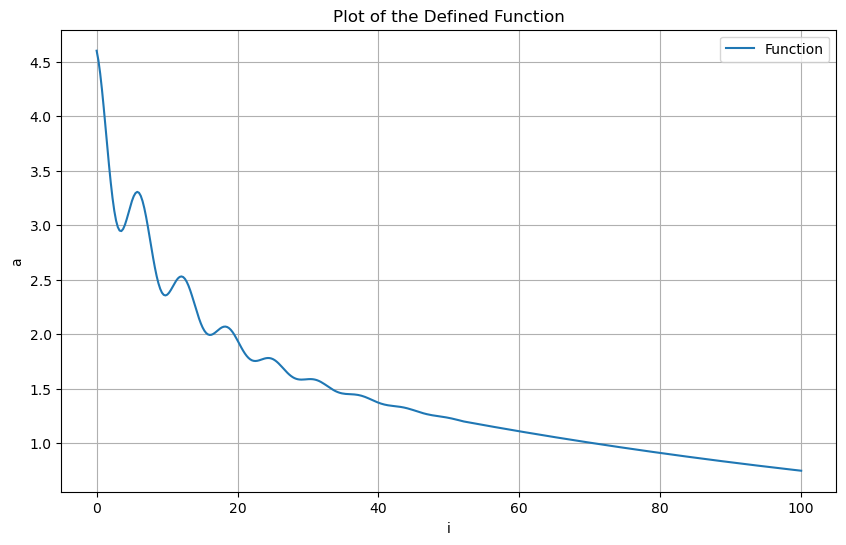

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定义最大迭代次数
imax = 100

# 创建迭代变量的数组
i_values = np.linspace(0, imax, 400)  # 400个点，更平滑的曲线

# 定义函数
def func(i, imax):
    return np.maximum(0.01, 2 * np.exp(-0.1 * i) * (1 + 0.3 * np.cos(i))) + 2 * np.exp(-i / imax)

# 计算每个点的函数值
a_values = func(i_values, imax)

# 绘制图像
plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(i_values, a_values, label='Function')

# 添加图例和标签
plt.legend()
plt.xlabel('i')
plt.ylabel('a')
plt.title('Plot of the Defined Function')

# 展示图像
plt.grid(True)
plt.show()

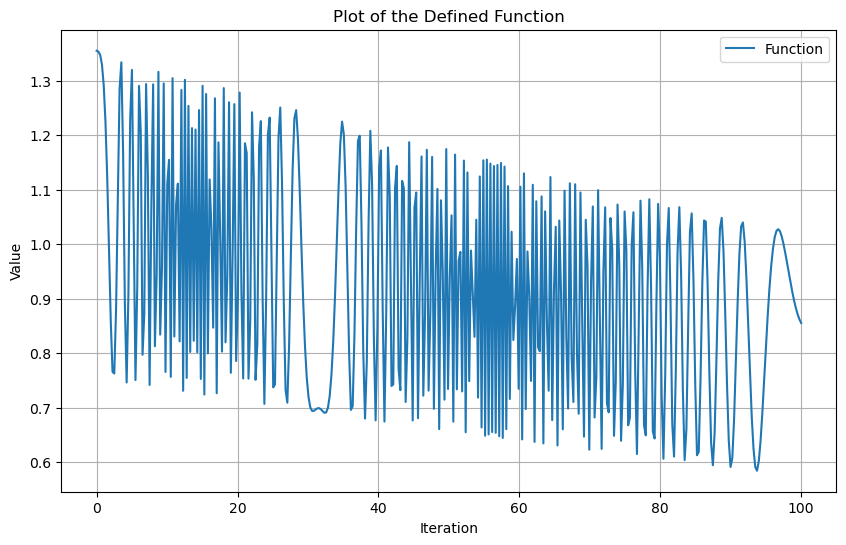

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 假设self.max_iter和self.m已经被定义
class Example:
    def __init__(self, max_iter, m):
        self.max_iter = max_iter
        self.m = m

# 实例化类
example = Example(max_iter=100, m=0.1)

# 定义函数
def func(iter, max_iter, m):
    return np.maximum(0.001, np.exp(-0.3 * iter / max_iter) * (1 + 0.3 * np.cos(iter * 50 / (1.01 ** iter))) + np.random.rand() * m)

# 创建迭代变量的数组，例如从0到max_iter
iter_values = np.linspace(0, example.max_iter, 400)  # 400个点，更平滑的曲线

# 计算每个点的函数值
# 注意：np.random.rand()在每次调用时都会产生不同的值，为了可重现的结果，我们设置随机种子
np.random.seed(0)
y_values = func(iter_values, example.max_iter, example.m)

# 绘制图像
plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(iter_values, y_values, label='Function')

# 添加图例和标签
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Plot of the Defined Function')

# 展示图像
plt.grid(True)
plt.show()

In [1]:
import numpy as np

def random_init(m, dim, low=-100, high=100):
    """ 纯随机初始化 """
    return np.random.uniform(low, high, size=(m, dim))

def heuristic_init(m, dim, low=-100, high=100):
    """ 启发式初始化，倾向于搜索空间的某个区域 """
    center = (low + high) / 2
    spread = (high - low) / 4  # 较小的扩展范围以集中于中心
    return np.random.uniform(center - spread, center + spread, size=(m, dim))

def mixed_init(m, dim, low=-100, high=100):
    """ 混合初始化：一半随机，一半启发式 """
    half_m = m // 2
    pop_random = random_init(half_m, dim, low, high)
    pop_heuristic = heuristic_init(m - half_m, dim, low, high)
    return np.vstack((pop_random, pop_heuristic))

# 参数设置
m = 10  # 种群大小
dim = 5  # 维度数
low = -100  # 下界
high = 100  # 上界

# 生成种群
pop_mixed = mixed_init(m, dim, low, high)

# 打印输出以查看结果
print("Mixed Initialization:\n", pop_mixed)


Mixed Initialization:
 [[ 23.25733852 -98.75284819  39.47755095   1.03387956 -28.42778845]
 [ 13.18380078 -52.57047092  62.09290159 -72.99264284 -99.02202258]
 [ 96.12945769  66.01336713 -65.83654771 -36.22986342 -12.65816787]
 [-71.73248299  36.5332228  -48.44953786 -69.98495372  65.29811274]
 [ 87.01765383  17.77720764  56.69828627  45.95653397  36.78492753]
 [-34.02590773  40.98947895  29.09495939 -44.67487012 -16.7346394 ]
 [ -7.3803123   12.36977657 -27.66003214 -26.17129344  -3.87337616]
 [-24.33858646 -10.48250795  19.83091371  14.56549328   1.9321867 ]
 [  7.05702079   5.03238256  19.75130811  46.45888396   1.58084424]
 [-20.7510811    9.91290782  -9.83222692  -8.28145327  46.22838063]]


In [2]:
pop = np.random.uniform(low=-100, high=100, size=(m, dim))

array([[-23.00103882,  -6.80878444, -12.1228556 ,  64.67096049,
         -6.73245948],
       [ 72.7154587 ,   4.7928436 , -88.01203907,  19.44132935,
        -75.53435278],
       [-99.21470836,  90.04335021, -30.63030426,  78.51285821,
        -23.67663911],
       [ 10.26505361, -32.19599218,  54.58359852,  76.8886575 ,
        -10.53837639],
       [-34.51072358,  36.62042007, -53.69387019, -92.85935749,
         34.72301151],
       [-80.76352722, -83.18939145, -66.87786236, -79.39567286,
         60.82778229],
       [-16.70070839,  75.22134185,  69.2233487 , -27.07975177,
         72.39022349],
       [-85.79516289,   2.06179652,  16.89872624, -47.64280585,
        -92.48609669],
       [ 63.64931832,  30.85509635,  36.09669305,  42.61816205,
         79.11653713],
       [  2.18885071,  48.76358093,  70.77416641,  96.34232562,
        -12.81204716]])

In [1]:
import pandas as pd
import os
from openpyxl import load_workbook

def append_to_excel(filename, data_list):
    # 将列表转换为DataFrame
    df = pd.DataFrame([data_list])

    # 检查文件是否存在
    if not os.path.isfile(filename):
        # 如果文件不存在，则创建新文件并写入数据
        df.to_excel(filename, index=False, header=False)
    else:
        # 如果文件存在，则追加数据
        book = load_workbook(filename)
        writer = pd.ExcelWriter(filename, engine='openpyxl')
        writer.book = book
        writer.sheets = {ws.title: ws for ws in book.worksheets}
        
        # 找到当前表中的最后一行
        startrow = writer.sheets['Sheet1'].max_row

        df.to_excel(writer, startrow=startrow, index=False, header=False)
        
        writer.save()

# 示例数据列表
data_list = [1, 2, 3, 4, 5]

# Excel文件名
filename = 'append_results.xlsx'

# 追加数据到Excel文件
append_to_excel(filename, data_list)

print(f"数据已成功写入 {filename}")


数据已成功写入 append_results.xlsx


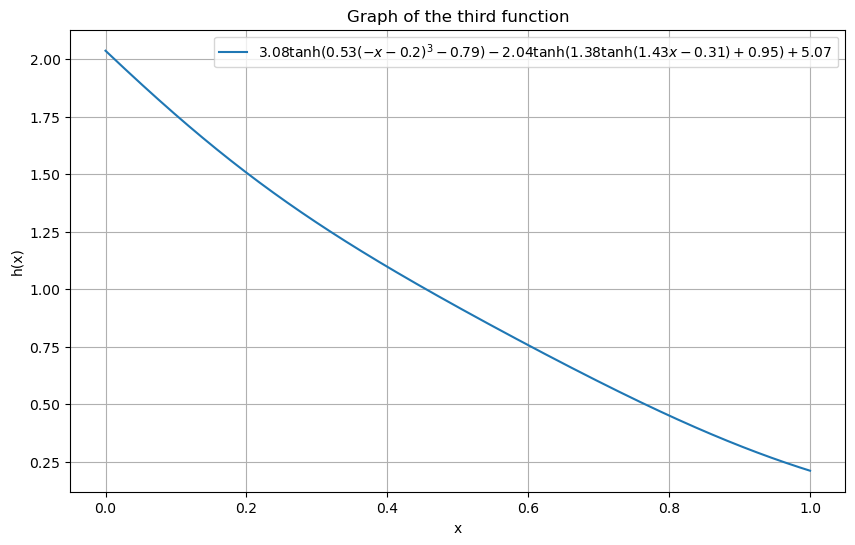

In [3]:
# Define the third function
def h(x):
    return 3.08 * np.tanh(0.53 * (-x - 0.2)**3 - 0.79) - 2.04 * np.tanh(1.38 * np.tanh(1.43 * x - 0.31) + 0.95) + 5.07

# Calculate y values for the third function
x = np.linspace(0, 1, 400)
y_third = h(x)

# Plot the third function
plt.figure(figsize=(10, 6))
plt.plot(x, y_third, label=r'$3.08\tanh(0.53(-x - 0.2)^3 - 0.79) - 2.04\tanh(1.38\tanh(1.43x - 0.31) + 0.95) + 5.07$')
plt.xlabel('x')
plt.ylabel('h(x)')
plt.title('Graph of the third function')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
import numpy as np
# 假设 C_max 是事先定义的最大容量值
C_max = 5000  # 示例最大容量
# 定义边界值
bounds = np.array([[0 + 1e-5, 1 - 1e-5], [0 + 1e-5, 1 - 1e-5], [1000, C_max]])

# 生成形状为 (30, 6) 的数组，每行的三个数具有不同的边界
# 我们假设每行的前两个数共享相同的边界，第三个数有独立的边界
random_array = np.zeros((30, 6))
for i in range(30):  # 遍历每一行
    # 对于每行的前两个数，使用相同的边界
    random_array[i, :2] = np.random.uniform(bounds[0, 0], bounds[0, 1], size=2)
    # 对于每行的第三个数，使用独立的边界
    random_array[i, 2] = np.random.uniform(bounds[2, 0], bounds[2, 1])
    # 填充剩余的三个数，这里我们简单地复制了前三个数的边界
    random_array[i, 3:5] = random_array[i, :2]  # x 和 y 的边界相同
    random_array[i, 5] = np.random.uniform(bounds[2, 0], bounds[2, 1])  # z 的边界

print(random_array)

[[3.50581982e-01 2.11626036e-01 4.54758519e+03 3.50581982e-01
  2.11626036e-01 2.70091076e+03]
 [6.84933425e-01 1.31142807e-01 3.77265091e+03 6.84933425e-01
  1.31142807e-01 4.69989427e+03]
 [7.87549946e-01 3.21618166e-01 4.50963348e+03 7.87549946e-01
  3.21618166e-01 4.54685234e+03]
 [4.22249336e-01 2.74105996e-01 3.07314932e+03 4.22249336e-01
  2.74105996e-01 1.68870845e+03]
 [3.13654359e-01 2.66905282e-01 3.64481510e+03 3.13654359e-01
  2.66905282e-01 4.82089358e+03]
 [2.19088132e-02 2.27689621e-01 4.03087656e+03 2.19088132e-02
  2.27689621e-01 1.18336680e+03]
 [7.17109644e-01 1.17061630e-01 3.60901137e+03 7.17109644e-01
  1.17061630e-01 4.71313792e+03]
 [3.21207203e-01 9.06387266e-01 3.99896531e+03 3.21207203e-01
  9.06387266e-01 3.61924296e+03]
 [6.74638541e-01 4.36511036e-01 4.75845704e+03 6.74638541e-01
  4.36511036e-01 1.89788482e+03]
 [2.97385775e-02 3.81285210e-01 2.32760825e+03 2.97385775e-02
  3.81285210e-01 4.58899783e+03]
 [7.61531778e-01 7.40692524e-01 2.58377794e+03 7.6

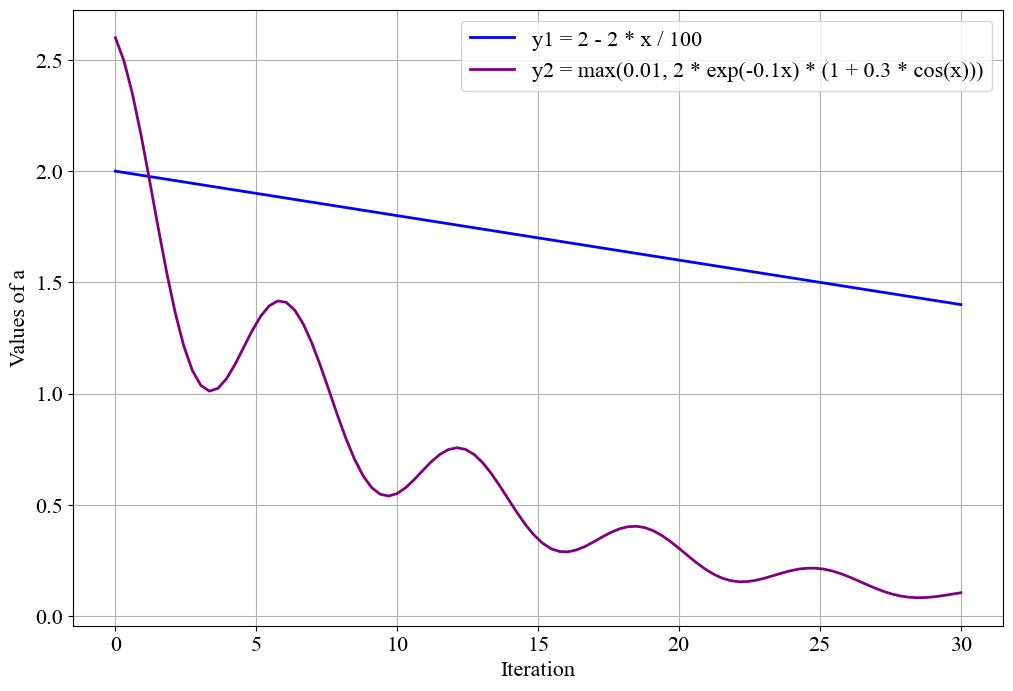

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set font properties to Times New Roman and increase font size
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Larger font size for default text

# Generate x values
x = np.linspace(0, 30, 100)

# Define the two functions
y1 = np.maximum(0.01, 2 * np.exp(-0.1 * x) * (1 + 0.3 * np.cos(x)))
y2 = 2 - 2 * x / 100

# Create the plot
plt.figure(figsize=(12, 8))  # Increased figure size
plt.plot(x, y2, color='blue', label=r'y1 = 2 - 2 * x / 100', linewidth=2)  # Thicker line
plt.plot(x, y1, color='purple', label=r'y2 = max(0.01, 2 * exp(-0.1x) * (1 + 0.3 * cos(x)))', linewidth=2)  # Thicker line

# Add grid lines
plt.grid(True)

# Add new x and y axis labels with larger font size
plt.xlabel('Iteration', fontsize=16)  # Set font size for x-axis label
plt.ylabel('Values of a', fontsize=16)  # Set font size for y-axis label

# Set larger font size for tick labels
plt.xticks(fontsize=16)  # Set font size for x-axis ticks
plt.yticks(fontsize=16)  # Set font size for y-axis ticks

# Add legend with larger font size
plt.legend(fontsize=16)

# Save the plot as an image with 300 DPI
plt.savefig('5.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()
